
# Swarmy Visualization Demo – Pygame

Demonstrates a Swarmy simulation visualized in real time using the PygameRenderer.
**Requirements:** You must run this notebook locally (not on Colab/JupyterHub) with a working GUI and `pygame` installed.
            

In [1]:
import sys
import pygame
from PIL import Image
from IPython.display import Image as IPyImage, display

# Add swarmy path if not installed system-wide
sys.path.append(r"C:\Users\miche\Documents\GitLab\swarmy")

pygame 2.6.1 (SDL 2.28.4, Python 3.9.13)
Hello from the pygame community. https://www.pygame.org/contribute.html


Step 0
Step 25
Step 50
Step 75
Step 100
Step 125
Step 150
Step 175
✅ GIF saved as swarm_simulation_pygame.gif


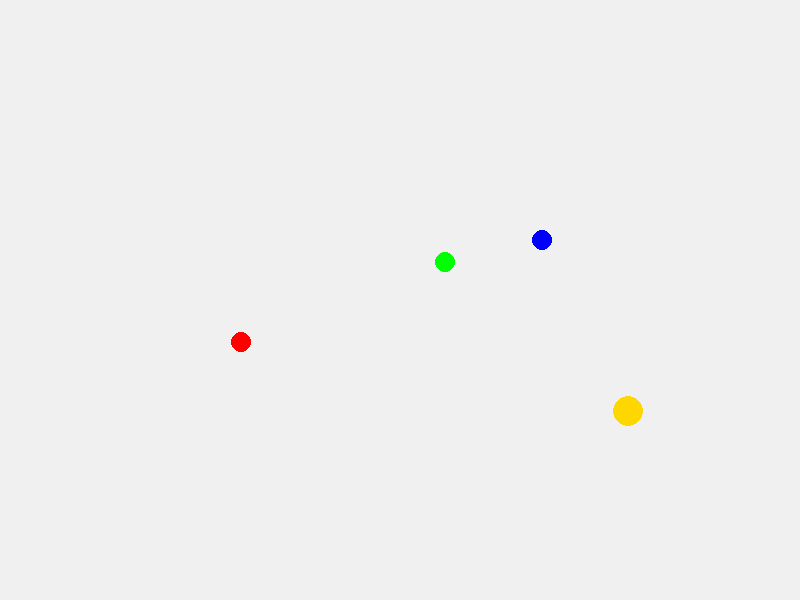

In [2]:
from swarmy import SwarmSimulation, SimulationConfig
from swarmy.visualization.pygame_renderer import PygameRenderer

# --- Setup simulation ---
config = SimulationConfig(num_agents=30, num_scouts=5)
sim = SwarmSimulation(config)

# Initialize Pygame normally (this will open a window)
pygame.init()
renderer = PygameRenderer(width=800, height=600)

frames = []

# --- Run simulation and capture frames ---
for step in range(200):
    sim.step()
    renderer.render(sim.get_state())

    # Capture the current display surface
    surface = pygame.display.get_surface()
    image_str = pygame.image.tostring(surface, 'RGB')
    image = Image.frombytes('RGB', surface.get_size(), image_str)
    frames.append(image)

    if step % 25 == 0:
        print(f"Step {step}")

pygame.quit()  # close the window

# --- Save GIF ---
output_path = "swarm_simulation_pygame.gif"
frames[0].save(
    output_path,
    save_all=True,
    append_images=frames[1:],
    duration=100,
    loop=0
)

print(f"✅ GIF saved as {output_path}")

# --- Display GIF inline ---
display(IPyImage(filename=output_path))
